# Customer Segmentation Analysis

## Oasis Infobyte Data Analytics Internship

### Customer Segmentation using RFM Analysis and K-Means Clustering

## 1. Import Libraries

In [39]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set plot style
sns.set_style("whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [41]:
# Load dataset

df = pd.read_csv(
    "../data/OnlineRetail.csv",
    encoding="latin1"
)

# Display first five rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom


### Dataset Shape

In [43]:
# Check number of rows and columns

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 299999
Columns: 8


### Dataset Information

In [45]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299999 entries, 0 to 299998
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    299999 non-null  object 
 1   StockCode    299999 non-null  object 
 2   Description  298890 non-null  object 
 3   Quantity     299999 non-null  int64  
 4   InvoiceDate  299999 non-null  object 
 5   UnitPrice    299999 non-null  float64
 6   CustomerID   215906 non-null  float64
 7   Country      299999 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 18.3+ MB


### Data Types

In [47]:
# Check data types

df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

### Missing Values

In [11]:
# Check missing values

df.isnull().sum()

InvoiceNo          0
StockCode          0
Description     1109
Quantity           0
InvoiceDate        0
UnitPrice          0
CustomerID     84093
Country            0
dtype: int64

### Duplicate Records

In [49]:
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2337


## 3. Data Cleaning and Preparation

### Remove Missing Customer IDs

In [51]:
# Remove records where CustomerID is missing

df = df.dropna(subset=["CustomerID"])

print("Rows after removing missing CustomerID:", df.shape[0])

Rows after removing missing CustomerID: 215906


### Remove Cancelled Transactions

In [17]:
# Remove cancelled invoices

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

print("Rows after removing cancelled transactions:", df.shape[0])

Rows after removing cancelled transactions: 210715


### Remove Invalid Quantities and Prices

In [53]:
# Keep only positive quantities and prices

df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

print("Rows after removing invalid transactions:", df.shape[0])

Rows after removing invalid transactions: 210698


### Create Total Purchase Amount

In [55]:
# Calculate total amount for each transaction

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom,20.34


## 4. Descriptive Statistics

In [27]:
# Calculate descriptive statistics

summary = pd.DataFrame({
    "Mean": df[["Quantity", "UnitPrice", "TotalAmount"]].mean(),
    "Median": df[["Quantity", "UnitPrice", "TotalAmount"]].median(),
    "Mode": df[["Quantity", "UnitPrice", "TotalAmount"]].mode().iloc[0],
    "Standard Deviation": df[["Quantity", "UnitPrice", "TotalAmount"]].std()
})

summary

,Mean,Median,Mode,Standard Deviation
Quantity,13.579256,6.00,1.00,168.087090
UnitPrice,3.216612,1.95,1.25,22.541482
TotalAmount,23.192359,12.72,15.00,202.795820


## 5. Customer Behaviour Analysis

### Customer Purchase Frequency

In [29]:
# Calculate number of unique customers

unique_customers = df["CustomerID"].nunique()

print("Number of unique customers:", unique_customers)

Number of unique customers: 3220


### Average Purchase Value

In [31]:
# Calculate average purchase value

average_purchase_value = df["TotalAmount"].mean()

print("Average Purchase Value:", round(average_purchase_value, 2))

Average Purchase Value: 23.19


### Customer Lifetime Value

In [33]:
# Calculate total spending per customer

customer_lifetime_value = (
    df.groupby("CustomerID")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

customer_lifetime_value.head(10)

CustomerID
14646.0    168503.10
18102.0    130537.23
14156.0     82955.79
12415.0     77265.72
12346.0     77183.60
14911.0     71354.65
17450.0     69650.88
17511.0     52918.59
15749.0     44534.30
16029.0     43933.86
Name: TotalAmount, dtype: float64

## 6. RFM Analysis

### Calculate RFM Features

In [59]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="mixed"
)

# Set reference date
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2011-08-13 15:22:00


In [61]:
# Calculate RFM values for each customer

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,207,1,77183.60
12347.0,11,5,2790.86
12348.0,130,3,1487.24
12350.0,191,1,334.40
12352.0,143,5,1561.81


### RFM Descriptive Statistics

In [63]:
# Display descriptive statistics for RFM features

rfm.describe()

,Recency,Frequency,Monetary
count,3220.000000,3220.000000,3220.000000
mean,85.627950,3.311180,1517.572532
std,71.570533,5.321541,5692.266544
min,1.000000,1.000000,2.900000
25%,25.000000,1.000000,257.897500
50%,66.000000,2.000000,543.980000
75%,134.250000,4.000000,1292.942500
max,255.000000,120.000000,168503.100000


In [65]:
# Create output folders

import os

os.makedirs("../output/figures", exist_ok=True)
os.makedirs("../output/cleaned_data", exist_ok=True)

print("Output folders created successfully.")

Output folders created successfully.


## 7. RFM Feature Distribution

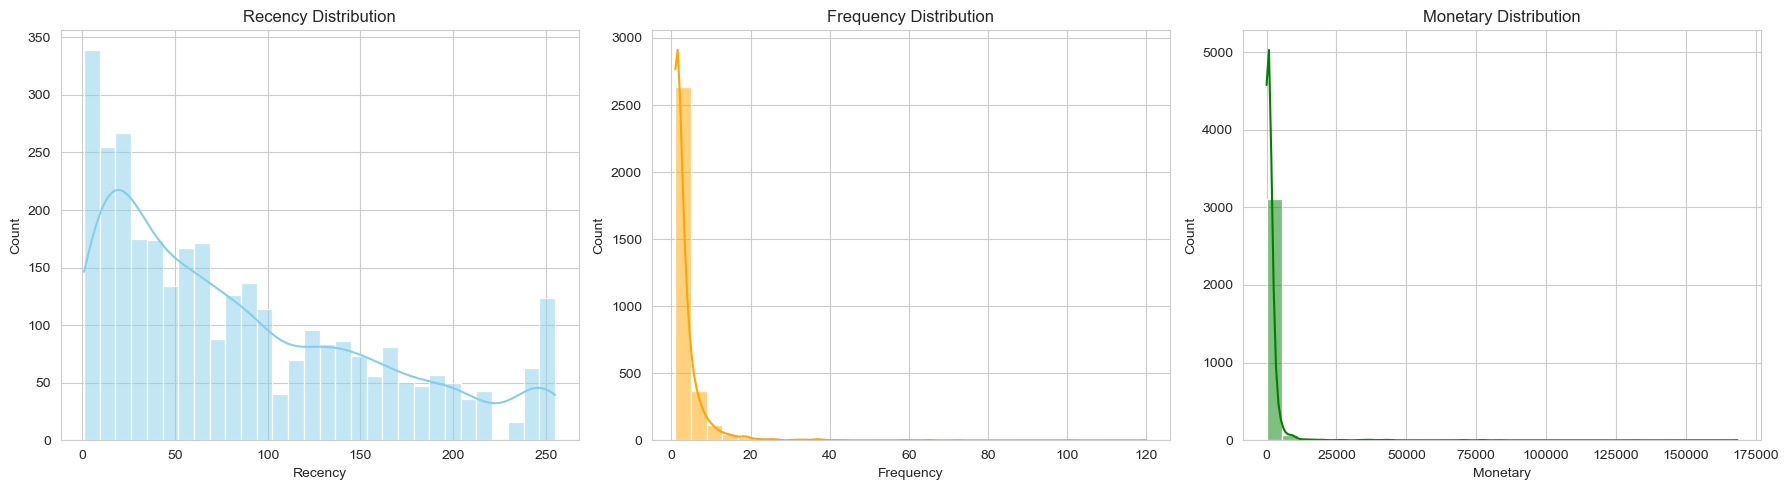

In [67]:
# Plot distribution of RFM features

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], bins=30, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], bins=30, kde=True, ax=axes[2], color="green")
axes[2].set_title("Monetary Distribution")

plt.tight_layout()

# Save image
plt.savefig(
    "../output/figures/rfm_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Correlation Analysis

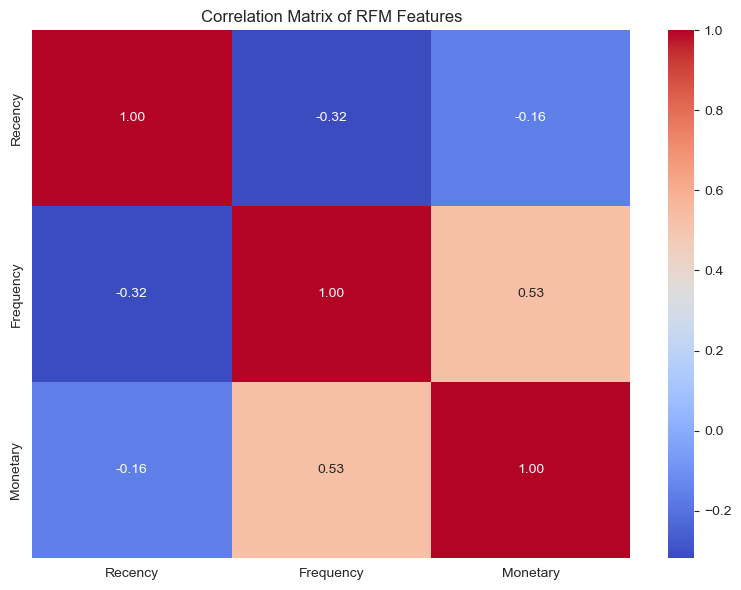

In [69]:
# Calculate correlation matrix

correlation_matrix = rfm.corr()

# Plot heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of RFM Features")

plt.tight_layout()

# Save image
plt.savefig(
    "../output/figures/rfm_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Data Standardisation

In [71]:
# Select RFM features

rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

# Standardise the features

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

# Convert back to DataFrame

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.696102,-0.434374,13.294841
12347.0,-1.042881,0.317405,0.223722
12348.0,0.620073,-0.058485,-0.005330
12350.0,1.472511,-0.434374,-0.207888
12352.0,0.801740,0.317405,0.007773


## 10. Finding the Optimal Number of Clusters

### Elbow Method

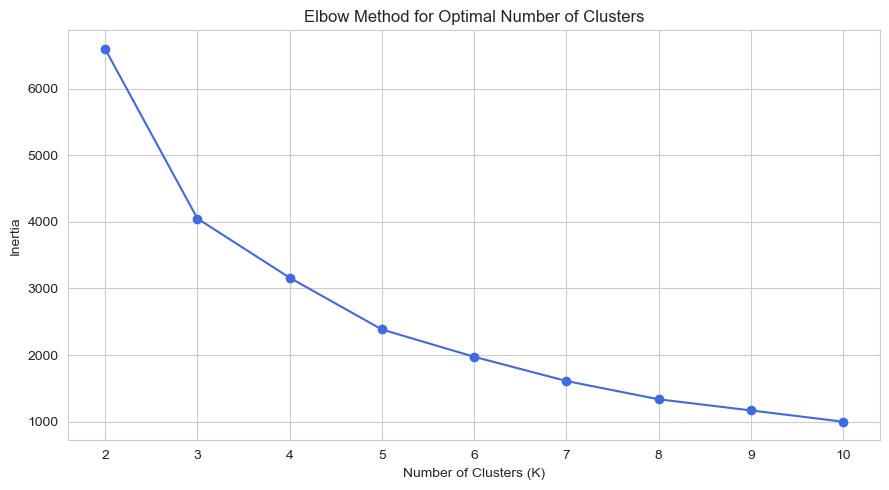

In [73]:
# Calculate Within-Cluster Sum of Squares for different K values

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(9, 5))

plt.plot(
    K_range,
    inertia,
    marker="o",
    color="royalblue"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(K_range)
plt.tight_layout()

# Save image
plt.savefig(
    "../output/figures/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Apply K-Means Clustering

In [77]:
# Select number of clusters based on the Elbow Method

optimal_k = 3

# Create K-Means model

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Fit model and assign cluster labels

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Display first few customers

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,207,1,77183.60,2
12347.0,11,5,2790.86,1
12348.0,130,3,1487.24,0
12350.0,191,1,334.40,0
12352.0,143,5,1561.81,0


## 12. Cluster Profiling

In [79]:
# Calculate average RFM values for each cluster

cluster_profile = (
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,173.81,1.42,457.41
1,42.58,3.79,1466.32
2,19.33,39.85,47224.99


## 13. Number of Customers in Each Cluster

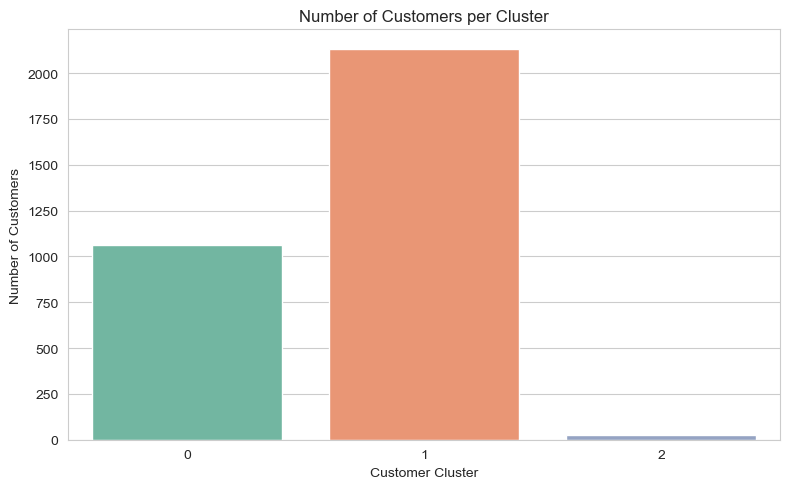

In [81]:
# Count customers in each cluster

cluster_counts = rfm["Cluster"].value_counts().sort_index()

# Plot customer count by cluster

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values,
    hue=cluster_counts.index,
    palette="Set2",
    legend=False
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save image
plt.savefig(
    "../output/figures/customers_per_cluster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 14. Cluster Visualisation

### Recency vs Frequency

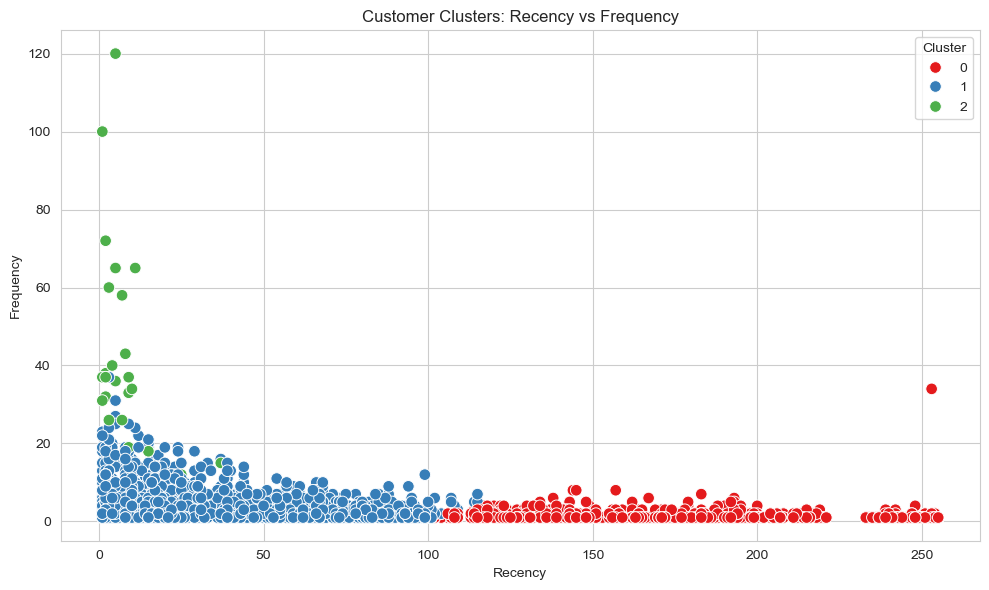

In [83]:
# Visualise clusters using Recency and Frequency

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="Set1",
    s=70
)

plt.title("Customer Clusters: Recency vs Frequency")
plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.legend(title="Cluster")

plt.tight_layout()

# Save image
plt.savefig(
    "../output/figures/cluster_recency_vs_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Monetary vs Frequency

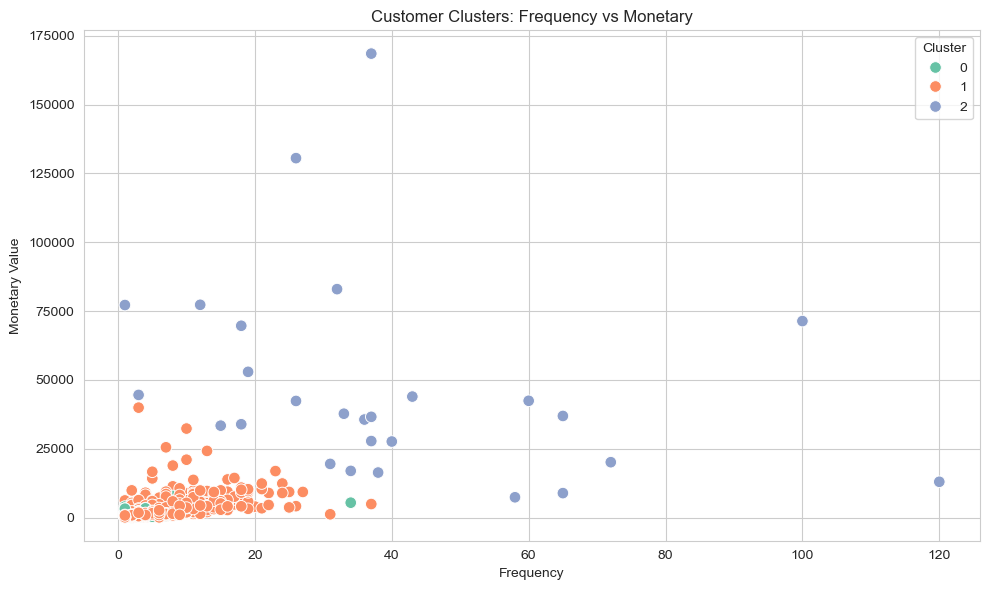

In [85]:
# Visualise clusters using Monetary and Frequency

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.title("Customer Clusters: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")

plt.tight_layout()

# Save image
plt.savefig(
    "../output/figures/cluster_frequency_vs_monetary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15. Customer Segment Analysis

In [89]:
# Add customer count to cluster profile

cluster_profile["Customer Count"] = rfm.groupby("Cluster").size()

cluster_profile

,Recency,Frequency,Monetary,Customer Count
Cluster,,,,
0,173.81,1.42,457.41,1061
1,42.58,3.79,1466.32,2132
2,19.33,39.85,47224.99,27


### Cleaned Data

In [91]:
# Save cleaned dataset

df.to_csv(
    "../output/cleaned_data/cleaned_online_retail.csv",
    index=False
)

# Save RFM dataset

rfm.to_csv(
    "../output/cleaned_data/customer_rfm.csv",
    index=True
)

# Save cluster profile

cluster_profile.to_csv(
    "../output/cleaned_data/cluster_profile.csv",
    index=True
)

print("Cleaned data saved successfully.")

Cleaned data saved successfully.
